In [1]:
import os
import json
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import cv2
from PIL import Image, ImageDraw, ImageFont

In [2]:
ROOT_PATH = '../data/raw/'
IMAGES_PATH = f'{ROOT_PATH}/images/'
TRAINING = f'{ROOT_PATH}/training.json'
TEST = f'{ROOT_PATH}/test.json'

TRAINING_coco = '../data/processed/training_coco.json'
OUTPUT_DIR = "output_demo/"

In [3]:
with open(TRAINING, 'r') as f:
    training_annotation = json.load(f)

with open(TEST, 'r') as f:
    test_annotation = json.load(f)

print(f'len training : {len(training_annotation)}')
print(f'len test : {len(test_annotation)}')

len training : 1208
len test : 120


In [4]:
item = training_annotation[0]

print(json.dumps(item, indent=4, ensure_ascii=False))

{
    "image": {
        "checksum": "676bb8e86fc2dbf05dd97d51a64ac0af",
        "pathname": "/images/8d02117d-6c71-4e47-b50a-6cc8d5eb1d55.png",
        "shape": {
            "r": 1200,
            "c": 1600,
            "channels": 3
        }
    },
    "objects": [
        {
            "bounding_box": {
                "minimum": {
                    "r": 1057,
                    "c": 1440
                },
                "maximum": {
                    "r": 1158,
                    "c": 1540
                }
            },
            "category": "red blood cell"
        },
        {
            "bounding_box": {
                "minimum": {
                    "r": 868,
                    "c": 1303
                },
                "maximum": {
                    "r": 971,
                    "c": 1403
                }
            },
            "category": "red blood cell"
        },
        {
            "bounding_box": {
                "minimum": {
               

In [5]:
# convert to coco annotation format

category_map = {}
category_list = []

def convert_to_coco_annotation(json_annotation, output_path):
    
    # ini COCO sturcture
    coco_output = {
        "images" : [],
        "annotations" : [],
        "categories" : []
    }
    
    annotation_id = 1
    image_id = 1
    
    for item in json_annotation:
        filename = os.path.basename(item['image']['pathname'])
        width = item['image']['shape']['c']
        height = item['image']['shape']['r']
    
        image_info = {
            "id": image_id,
            "file_name": filename,
            "width": width,
            "height": height
        }
        
        coco_output['images'].append(image_info)
    
        for obj in item['objects']:
            category_name = obj['category']
            if category_name not in category_map:
                category_map[category_name] = len(category_map)
                category_list.append({
                    "id": category_map[category_name],
                    "name": category_name
                })
                
            bbox = obj["bounding_box"]
            x_min = bbox["minimum"]["c"]
            y_min = bbox["minimum"]["r"]
            x_max = bbox["maximum"]["c"]
            y_max = bbox["maximum"]["r"]
            width = x_max - x_min
            height = y_max - y_min
    
            annotation = {
                "id": annotation_id,
                "image_id": image_id,
                "category_id": category_map[category_name],
                "bbox": [x_min, y_min, width, height],
                "area": width * height,
                "iscrowd": 0
            }
            
            coco_output["annotations"].append(annotation)
            annotation_id += 1
    
        image_id += 1

    if not coco_output['categories']:
        coco_output['categories'] = category_list

    # Save to file (optional)
    with open(output_path, "w") as f:
        json.dump(coco_output, f, indent=2)
    print(f"Converted {image_id - 1} images and {annotation_id - 1} annotations to COCO format.")

In [6]:
COCO_TRAINING = './../data/processed/training_coco.json'
COCO_TEST = './../data/processed/test_coco.json'

convert_to_coco_annotation(training_annotation, COCO_TRAINING)
convert_to_coco_annotation(test_annotation, COCO_TEST)

# The ID is repeated because these are two distinct sets

Converted 1208 images and 80113 annotations to COCO format.
Converted 120 images and 5922 annotations to COCO format.


In [7]:
category_list

[{'id': 0, 'name': 'red blood cell'},
 {'id': 1, 'name': 'trophozoite'},
 {'id': 2, 'name': 'schizont'},
 {'id': 3, 'name': 'difficult'},
 {'id': 4, 'name': 'ring'},
 {'id': 5, 'name': 'leukocyte'},
 {'id': 6, 'name': 'gametocyte'}]

In [8]:
with open(COCO_TRAINING) as f:
    training_coco = json.load(f)

images_train = pd.DataFrame(training_coco['images'])
annotations_train = pd.DataFrame(training_coco['annotations'])
categories_train = pd.DataFrame(training_coco['categories'])

print("==== Training Data Summary:")
print(f"Total Images: {len(images_train)}")
print(f"Total Annotations: {len(annotations_train)}")
print(f"Total Categories: {len(categories_train)}")


==== Training Data Summary:
Total Images: 1208
Total Annotations: 80113
Total Categories: 7


In [9]:
with open(COCO_TEST) as f:
    test_coco = json.load(f)

images_test = pd.DataFrame(test_coco['images'])
annotations_test = pd.DataFrame(test_coco['annotations'])
categories_test = pd.DataFrame(test_coco['categories'])

print("==== Test Data Summary:")
print(f"Total Images: {len(images_test)}")
print(f"Total Annotations: {len(annotations_test)}")
print(f"Total Categories: {len(categories_test)}")

==== Test Data Summary:
Total Images: 120
Total Annotations: 5922
Total Categories: 7


In [10]:
all_annotations = pd.concat([annotations_train, annotations_test], ignore_index=True)
all_annotations

,id,image_id,category_id,bbox,area,iscrowd
0,1,1,0,"[1440, 1057, 100, 101]",10100,0
1,2,1,0,"[1303, 868, 100, 103]",10300,0
2,3,1,0,"[900, 578, 108, 111]",11988,0
3,4,1,0,"[611, 304, 102, 104]",10608,0
4,5,1,0,"[881, 198, 122, 114]",13908,0
...,...,...,...,...,...,...
86030,5918,120,0,"[694, 1047, 93, 98]",9114,0
86031,5919,120,0,"[1381, 543, 83, 74]",6142,0
86032,5920,120,4,"[1725, 1041, 155, 155]",24025,0
86033,5921,120,4,"[374, 526, 134, 127]",17018,0


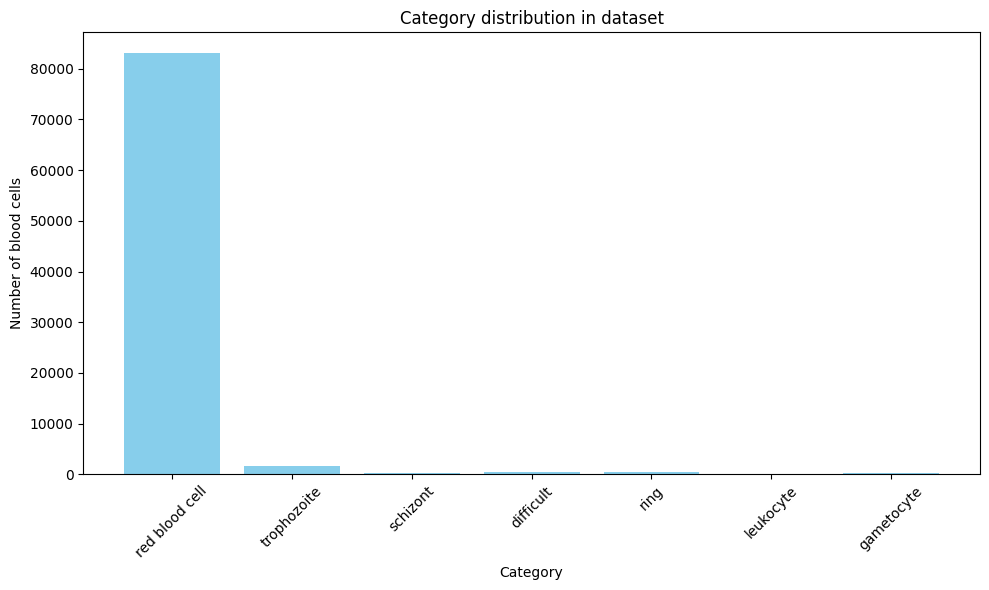

In [11]:
# plot category distribution all dataset

all_annotations = pd.concat([annotations_train, annotations_test], ignore_index=True)

category_counts = all_annotations['category_id'].value_counts().sort_index()

category_df = pd.DataFrame(category_list).set_index('id')
category_names = category_df.loc[category_counts.index, 'name']

plt.figure(figsize=(10,6))
plt.bar(category_names, category_counts.values, color='skyblue')
plt.xlabel('Category')
plt.ylabel('Number of blood cells')
plt.title('Category distribution in dataset')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('./../reports/figures/exploratory/category_distribution_dataset.png')

plt.show()

### Image binarization

In [12]:
print(category_counts)
print(category_names)

category_id
0    83034
1     1584
2      190
3      446
4      522
5      103
6      156
Name: count, dtype: int64
category_id
0    red blood cell
1       trophozoite
2          schizont
3         difficult
4              ring
5         leukocyte
6        gametocyte
Name: name, dtype: object


In [13]:
non_infected = ['red blood cell', 'leukocyte']
infected = ['trophozoite', 'schizont', 'ring', 'gametocyte']

dict_non_infected = category_names[category_names.isin(non_infected)]
dict_infected = category_names[category_names.isin(infected)]

non_infected_ids = (dict_non_infected.index).to_list()
infected_ids = (dict_infected.index).to_list()

In [14]:
cells_per_image = annotations_train.groupby("image_id").size()

df_cells = pd.DataFrame(cells_per_image, columns=["cell_count"])

df_cells.describe()

,cell_count
count,1208.000000
mean,66.318709
std,34.575569
min,9.000000
25%,43.750000
50%,59.000000
75%,81.000000
max,223.000000


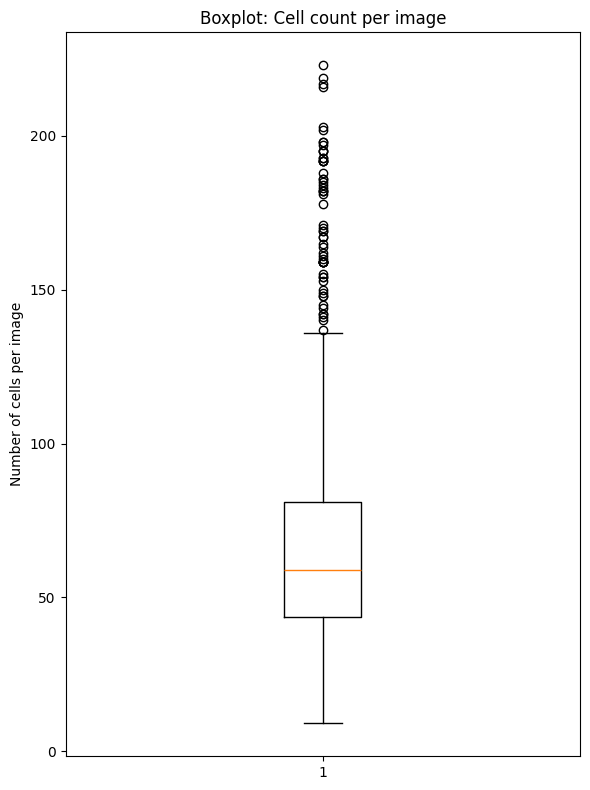

In [15]:
plt.figure(figsize=(6, 8))
plt.boxplot(df_cells["cell_count"], vert=True)
plt.ylabel("Number of cells per image")
plt.title("Boxplot: Cell count per image")
plt.tight_layout()

plt.savefig('./../reports/figures/exploratory/boxplot_cell_count_per_image.png')

plt.show()

In [16]:
infected = all_annotations[all_annotations["category_id"].isin(infected_ids)]

infected_count_per_image = (
    infected
    .groupby("image_id")
    .size()
    .reset_index(name="num_infected")
)

infected_count_per_image.describe()

,image_id,num_infected
count,934.000000,934.000000
mean,617.611349,2.625268
std,364.807524,1.900201
min,1.000000,1.000000
25%,289.250000,1.000000
50%,635.500000,2.000000
75%,942.750000,3.750000
max,1208.000000,12.000000


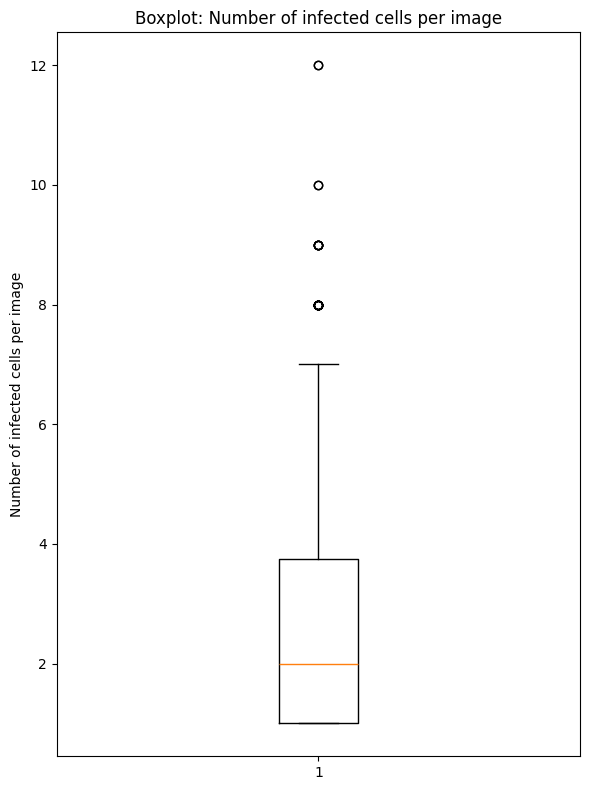

In [17]:
plt.figure(figsize=(6, 8))
plt.boxplot(infected_count_per_image["num_infected"], vert=True)
plt.ylabel("Number of infected cells per image")
plt.title("Boxplot: Number of infected cells per image")
plt.tight_layout()

plt.savefig('./../reports/figures/exploratory/boxplot_infected_cell_count_per_image.png')

plt.show()

In [18]:
label_map = {
    **{cid: 0 for cid in non_infected_ids},
    **{cid: 1 for cid in infected_ids},
}

annotations_train["binary_label"] = annotations_train["category_id"].map(label_map)

In [19]:
df_non = annotations_train[annotations_train["binary_label"] == 0]
df_inf = annotations_train[annotations_train["binary_label"] == 1]

min_n = min(len(df_non), len(df_inf))

df_non_sampled = df_non.sample(n=min_n, random_state=42)
df_inf_sampled = df_inf.sample(n=min_n, random_state=42)

balanced_annotations = pd.concat([df_non_sampled, df_inf_sampled]).sample(frac=1, random_state=42)

balanced_annotations.shape


(4298, 7)

In [20]:
balanced_annotations

,id,image_id,category_id,bbox,area,iscrowd,binary_label
71112,71113,1082,0,"[48, 136, 120, 110]",13200,0,0.0
59989,59990,922,1,"[1236, 320, 138, 155]",21390,0,1.0
70713,70714,1076,0,"[1007, 1090, 94, 97]",9118,0,0.0
57069,57070,880,1,"[412, 604, 91, 98]",8918,0,1.0
53731,53732,828,1,"[57, 108, 125, 118]",14750,0,1.0
...,...,...,...,...,...,...,...
75199,75200,1136,1,"[455, 595, 120, 130]",15600,0,1.0
35009,35010,547,0,"[751, 274, 117, 129]",15093,0,0.0
57866,57867,892,1,"[276, 903, 130, 126]",16380,0,1.0
667,668,14,1,"[717, 370, 122, 120]",14640,0,1.0


In [21]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

with open(TRAINING_coco, "r", encoding="utf-8") as f:
    coco = json.load(f)

images_dict = {img["id"]: img for img in coco["images"]}
categories_dict = {cat["id"]: cat["name"] for cat in coco["categories"]}

examples = {cat["id"]: [] for cat in coco["categories"]}
used_images_per_category = {cat["id"]: set() for cat in coco["categories"]}

for ann in coco["annotations"]:
    cat_id = ann["category_id"]
    img_id = ann["image_id"]

    if len(examples[cat_id]) >= 3:
        continue

    if img_id in used_images_per_category[cat_id]:
        continue

    examples[cat_id].append(ann)
    used_images_per_category[cat_id].add(img_id)

for cat_id, anns in examples.items():

    label = categories_dict[cat_id]

    for i, ann in enumerate(anns):

        img_id = ann["image_id"]
        x, y, w, h = map(int, ann["bbox"])

        img_info = images_dict[img_id]
        filename = img_info["file_name"]

        img_path = os.path.join(IMAGES_PATH, filename)
        img = cv2.imread(img_path)

        if img is None:
            print(f"Error loading: {img_path}")
            continue

        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 0, 255), 4)

        pil_img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        draw = ImageDraw.Draw(pil_img)

        try:
            font = ImageFont.truetype("DejaVuSans-Bold.ttf", 32)
        except:
            font = ImageFont.load_default()

        tb = draw.textbbox((0, 0), label, font=font)
        tw, th = tb[2] - tb[0], tb[3] - tb[1]

        draw.rectangle([x, y - th - 6, x + tw + 6, y], fill=(255, 255, 255))
        draw.text((x + 3, y - th - 3), label, fill=(0, 0, 0), font=font)

        img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

        out_path = os.path.join(OUTPUT_DIR, f"{label}_ex{i+1}_img{img_id}.png")
        cv2.imwrite(out_path, img)

        print(f"Saved: {out_path}")


Saved: output_demo/red blood cell_ex1_img1.png
Saved: output_demo/red blood cell_ex2_img2.png
Saved: output_demo/red blood cell_ex3_img3.png
Saved: output_demo/trophozoite_ex1_img1.png
Saved: output_demo/trophozoite_ex2_img6.png
Saved: output_demo/trophozoite_ex3_img13.png
Saved: output_demo/schizont_ex1_img3.png
Saved: output_demo/schizont_ex2_img5.png
Saved: output_demo/schizont_ex3_img30.png
Saved: output_demo/difficult_ex1_img3.png
Saved: output_demo/difficult_ex2_img5.png
Saved: output_demo/difficult_ex3_img8.png
Saved: output_demo/ring_ex1_img4.png
Saved: output_demo/ring_ex2_img7.png
Saved: output_demo/ring_ex3_img16.png
Saved: output_demo/leukocyte_ex1_img5.png
Saved: output_demo/leukocyte_ex2_img14.png
Saved: output_demo/leukocyte_ex3_img21.png
Saved: output_demo/gametocyte_ex1_img9.png
Saved: output_demo/gametocyte_ex2_img10.png
Saved: output_demo/gametocyte_ex3_img15.png
